# **Assignment Week 3 - Time Series Forecasting**

Choose one of the dataset proposed, and fill the following boxes with your code. Then run your code and submit the file with your code and the output. 

**Import the Libraries**

In [1]:
import pandas as pd # Load CSV file and handle date time index 
import numpy as np  # Generate arrays and random number 
import matplotlib.pyplot as plt # for line plot ACF and pacf
import seaborn as sns  #statistical plot
from statsmodels.tsa.seasonal import seasonal_decompose, STL  # to decompose pattern
from statsmodels.tsa.stattools import adfuller, acf, pacf   #stationarity + ARIMA parameters
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt  #Holt-Winters forecasting
from statsmodels.tsa.api import SimpleExpSmoothing  #simple smoothing 
from statsmodels.tsa.arima.model import ARIMA           #classic forecasting model
from pmdarima import auto_arima                         #automatic ARIMA
from statsmodels.tsa.forecasting.theta import ThetaModel    #strong trending model
from statsmodels.tsa.statespace.sarimax import SARIMAX  #seasonal ARIMA
from sklearn.ensemble import RandomForestRegressor  #ML forcast
from xgboost import XGBRegressor  # ML Forcast
from sklearn.metrics import mean_squared_error, mean_absolute_error # error evaluation
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split # CV for time series

**Load the Dataset**

If your dataset is a .csv file, use the pandas function *read_csv*, if it's a .xlsx file, use *read_excel*

In [2]:
data = pd.read_csv('Daily_Total_Female_Births_California.csv')  # Loade CSv file
data.head() # to show first 5 row 

,Date,Births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


**Plot the time series**

Do not split the dataset yet, just plot the time series

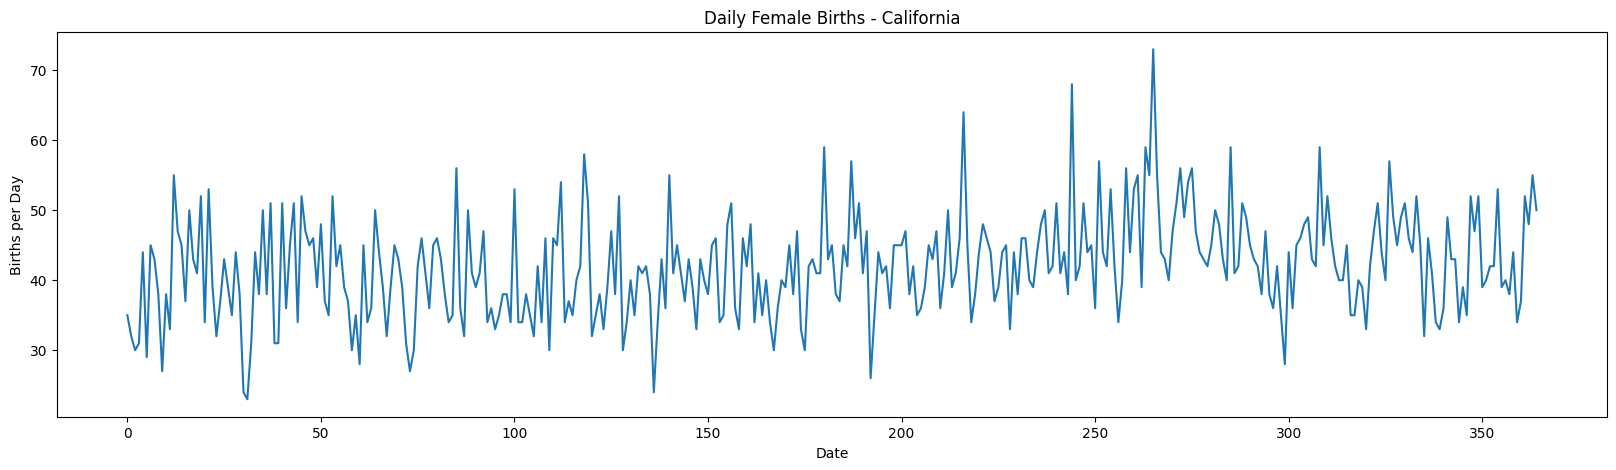

In [3]:
plt.figure(figsize=(20,5))  # Plot area
plt.plot(data['Births'])
plt.title('Daily Female Births - California')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.show()


**Decompose your time series**

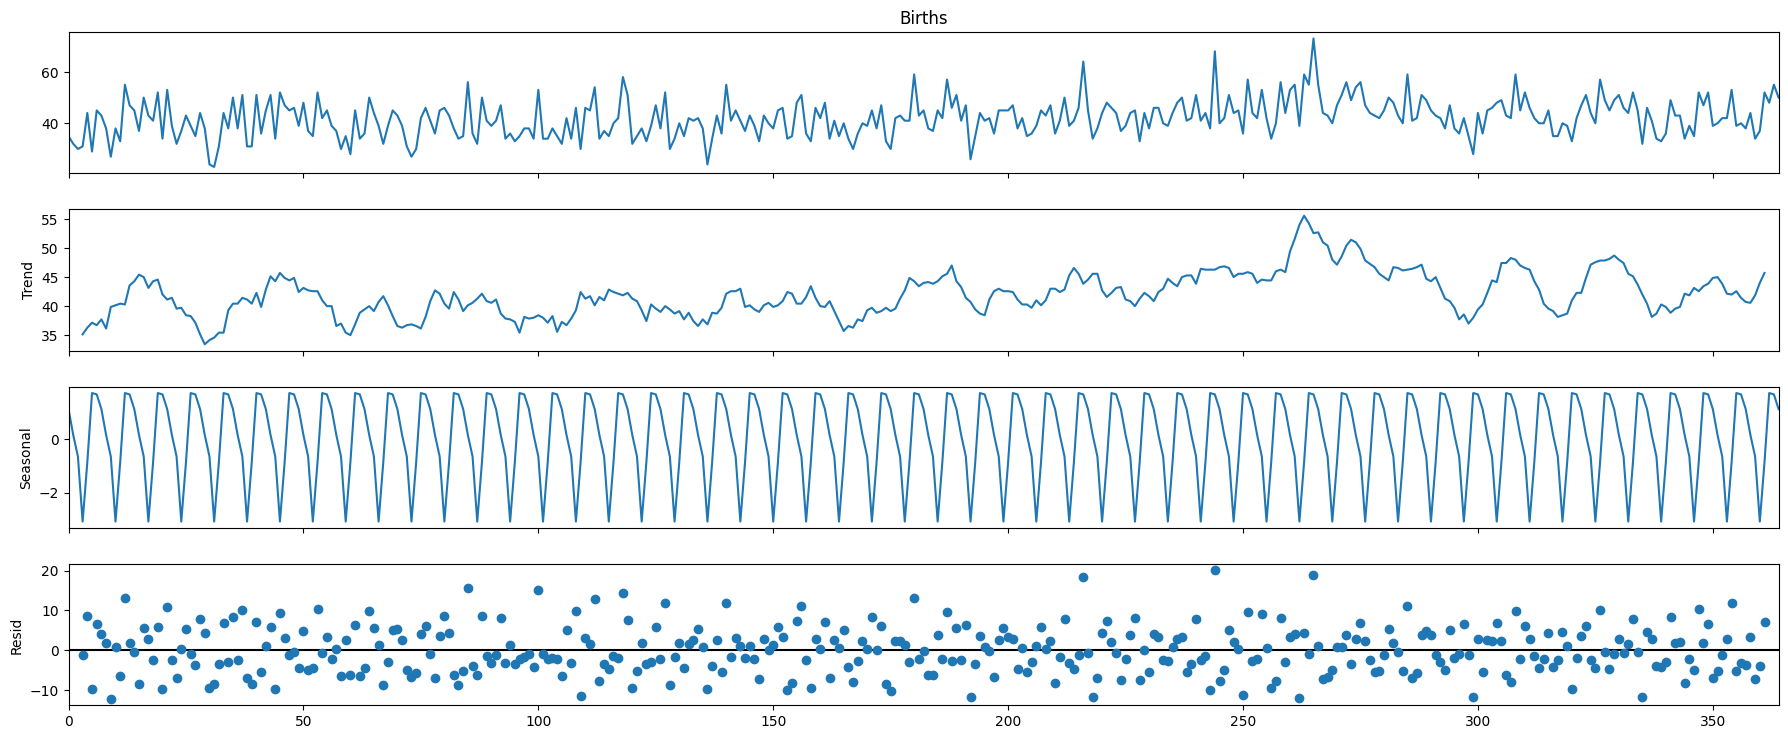

In [4]:
# Decompose the time series
decomposition = seasonal_decompose(data['Births'], model='additive', period=7)  # represent data every 7 days

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(20, 8)
plt.show()

From the results you obtained, could you say if the dataset is multiplicative or additive?

*#aswer here*

Based on the decomposition results, this dataset looks additive rather than multiplicative.
The main reason is that the seasonal pattern stays about the same size over the whole time period. The ups and downs in the seasonal component do not get bigger or smaller when the overall level of births changes.

If the dataset were multiplicative, I would expect the seasonal effect to grow when the trend increases and shrink when the trend decreases. But in my plot, the seasonal curve has a constant amplitude, meaning the seasonal effect is independent of the level of the series.

Also, the values in the dataset stay in a relatively small range (around 30–60 births per day), which fits better with an additive structure. Multiplicative models are usually used when the data varies with larger scales or when the variance increases with the level, which does not happen here.

So overall, the decomposition suggests the time series is additive.


**Check if the data is stationary**

In [5]:
# ADF Test
result = adfuller(data['Births'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -4.808291253559763
p-value: 5.243412990149865e-05
Critical Value (1%): -3.448748905151901
Critical Value (5%): -2.8696473721448728
Critical Value (10%): -2.5710891239349585


Is the data stationary? why?

*#answer here*

Yes, the data is stationary.

To check stationarity, I used the Augmented Dickey-Fuller (ADF) test. The goal of this test is to see whether the time series changes over time or stays stable. In the ADF test, the null hypothesis assumes that the data is not stationary, while the alternative hypothesis assumes that it is stationary.

From the results, the p-value is much smaller than 0.05, so we reject the null hypothesis. Also, the ADF statistic is lower than the critical values at the 1%, 5%, and 10% significance levels. This confirms that the time series does not have a unit root.

This means that the data does not show a strong trend or changing variance over time. The average number of births and the variability around it remain fairly constant throughout the period. Therefore, the dataset can be considered stationary, and no additional transformation (such as differencing) is needed before applying forecasting models.

If the data is not stationary, fix it here:

In [6]:
# leave blank if the data is stationary

Is the data stationary now? If not, fix it here:

In [7]:
# leave blank if the data is stationary

**Plot autocorrelation (ACF) and partial autocorrelation (PACF)** 

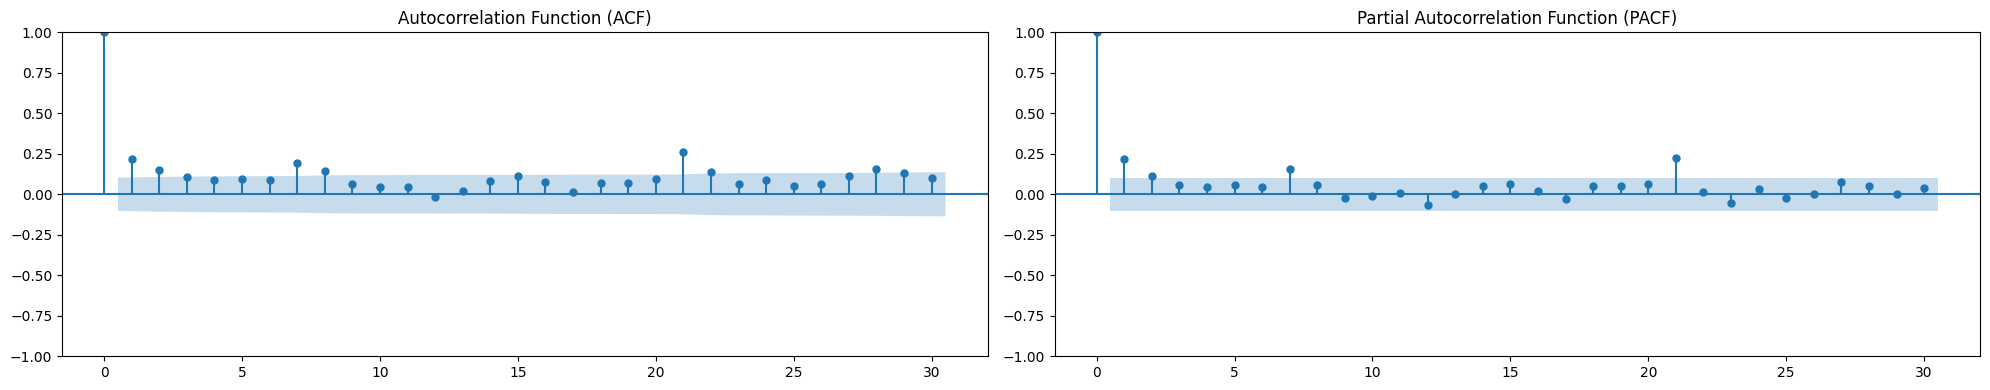

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(20,4))

# ACF
plot_acf(data['Births'], lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(data['Births'], lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

Are there significant spikes? Which lags are significant?

*#answer here*

Yes, there are a few significant spikes in both the ACF and PACF plots.

In the ACF plot, there is a significant spike at lag 1, which lies outside the confidence interval. This indicates that the current number of births is correlated with the previous day. After lag 1, most of the autocorrelation values fall within the confidence bounds, suggesting that the dependence decreases quickly for higher lags. There is also a small spike around lag 20, but it is weaker compared to lag 1.
In the PACF plot, the most noticeable and significant spike is also at lag 1. After this lag, the partial autocorrelations are mostly within the confidence interval, which means that additional lags do not contribute much once the first lag is taken into account.
Overall, lag 1 is the most significant lag in both ACF and PACF plots. This suggests that the time series has strong short-term dependence and that a low-order autoregressive or ARIMA model would be appropriate.
ACF and PACF tell us the ARIMA order: PACF → p, ACF → q.

**(Bonus): Find Structural breaks**

The code has to be in R, you can run it on R studio and paste it here.

*#paste code here*

Are there any structural breaks? How many? When?

*#answer here*

**Preprocessing**

**1. Remove trends and seasonality**

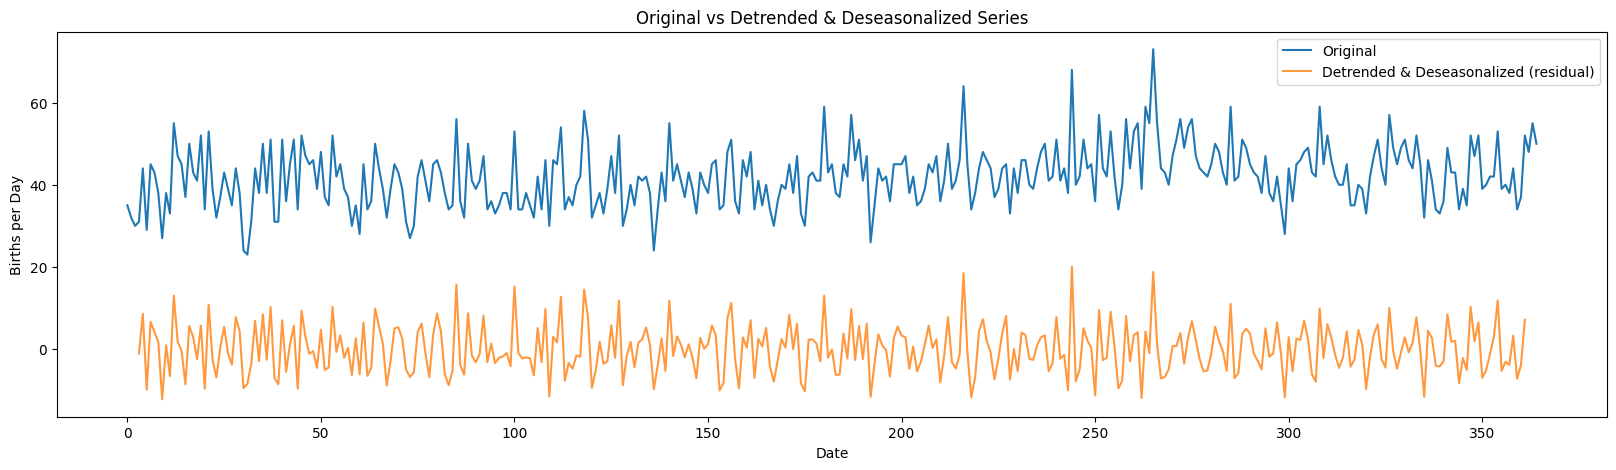

In [ ]:
# Decompose the original series
decomp = seasonal_decompose(data['Births'], model='additive', period=7)
# residual component = (original - trend - seasonal)
births_detrended = decomp.resid.dropna()
# Plot original vs detrended/deseasonalized
plt.figure(figsize=(20,5))
plt.plot(data['Births'], label='Original')
plt.plot(births_detrended, label='Detrended & Deseasonalized (residual)', alpha=0.8) # plotting multiple lines togather
plt.title('Original vs Detrended & Deseasonalized Series')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.legend()
plt.show()

**2. Smooth out the outliers**

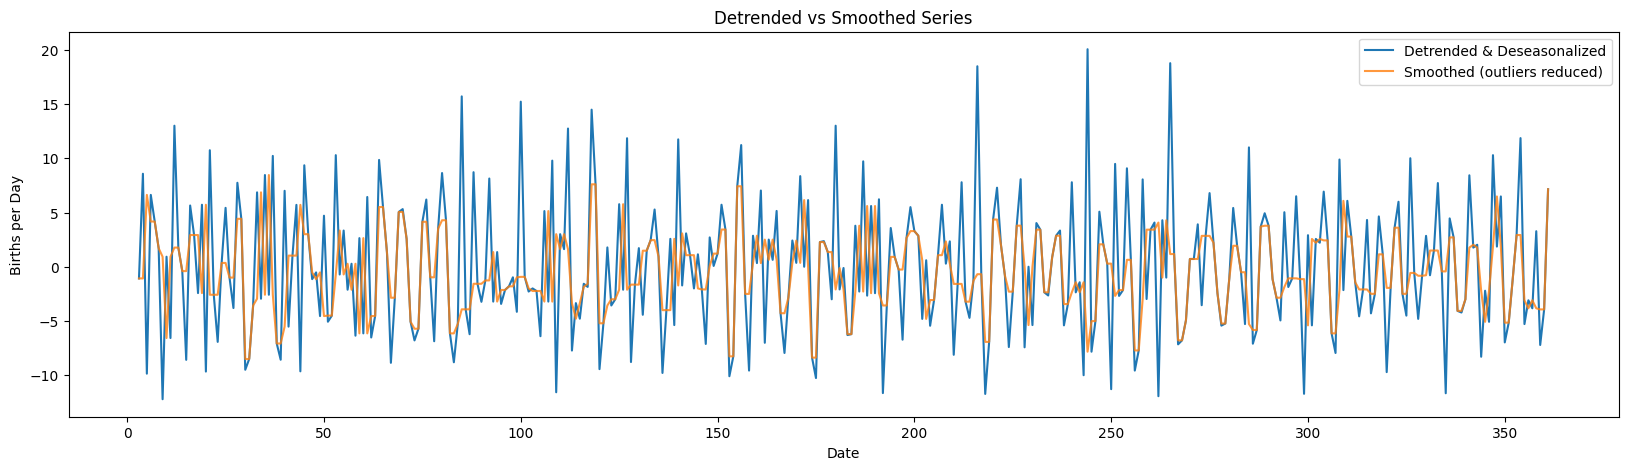

In [ ]:

#  to smooth small outliers (window of 3 days)
births_smoothed = births_detrended.rolling(window=3, center=True).median()

# Fill any NaNs at the edges with the original detrended values
births_smoothed = births_smoothed.fillna(births_detrended)

# Plot detrended vs smoothed series
plt.figure(figsize=(20,5))
plt.plot(births_detrended, label='Detrended & Deseasonalized')
plt.plot(births_smoothed, label='Smoothed (outliers reduced)', alpha=0.8)
plt.title('Detrended vs Smoothed Series')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.legend()
plt.show()

**3. Plot the results**

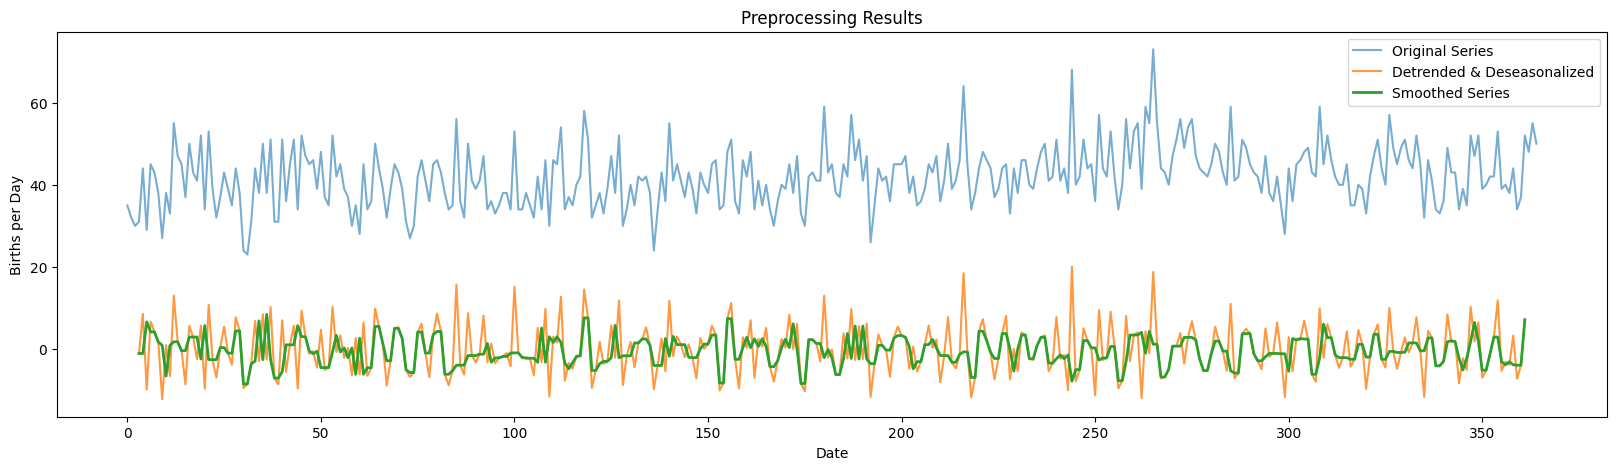

In [11]:
plt.figure(figsize=(20,5))

plt.plot(data['Births'], label='Original Series', alpha=0.6)
plt.plot(births_detrended, label='Detrended & Deseasonalized', alpha=0.8)
plt.plot(births_smoothed, label='Smoothed Series', linewidth=2)

plt.title('Preprocessing Results')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.legend()
plt.show()

Is there a lot of difference? What can you say about the original data seeing the difference with the preprocessed one?

*#answer here*

From the preprocessing plots, there is a noticeable difference between the original data and the preprocessed data, but the difference is not very large. The original time series shows daily fluctuations around a fairly stable level, with some noise and a few spikes, but no very strong long-term trend.

After removing the trend and seasonality, the detrended and deseasonalized series fluctuates around zero. This shows that the main components of the original data, such as trend and seasonal effects, have been successfully removed. What remains mostly represents random variations in the data.

When comparing the detrended series with the smoothed series, the smoothed version clearly reduces sharp peaks and sudden drops. This indicates that smoothing helps in reducing the effect of outliers and noise while keeping the general behavior of the series unchanged.

Overall, the preprocessing steps clean the data and make it more stable, but they do not drastically change its structure. This suggests that the original data is already relatively stable, which explains why simple forecasting models performed well earlier. Preprocessing mainly improves clarity and reduces noise rather than transforming the data completely.

**Split the data in train and test** and plot the result

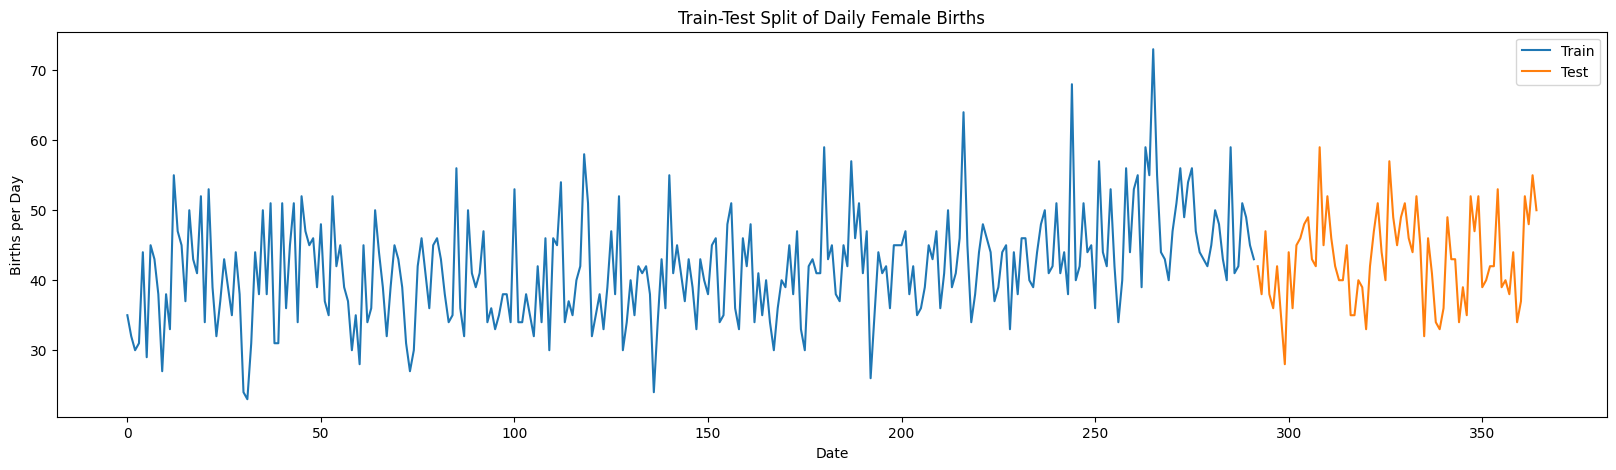

In [12]:
# Split data: 80% train, 20% test
train_size = int(len(data) * 0.8) #80% train size and 20% testing
train = data.iloc[:train_size]
test = data.iloc[train_size:]
# Plot train and test sets
plt.figure(figsize=(20,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.title('Train-Test Split of Daily Female Births')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.legend()
plt.show()


Experiment with different train-test splits/forecasting horizons (1 for 1 point, 3 for the possibility of having 3 points) to determine which prediction horizon yields the best results for various models. The primary aim is to observe and compare how each model performs under varying conditions and to identify scenarios where one model outperforms others.

Task: Use the models presented in the *TimeSeriesNotebook.ipynb* to **forecast** your time series data. Then, **evaluate** the performance of each model both through **manual validation** and **cross-validation (bonus)**.

Examples (train,test) : (0.8 * data,0.2 * data) ; (0.7 * data,0.3 * data); (0.6 * data, 0.4 * data); but also fixed numbers like (x, y) (for a dataset of x+y length)

**Forecasting: Choose between 3-5 models presented**

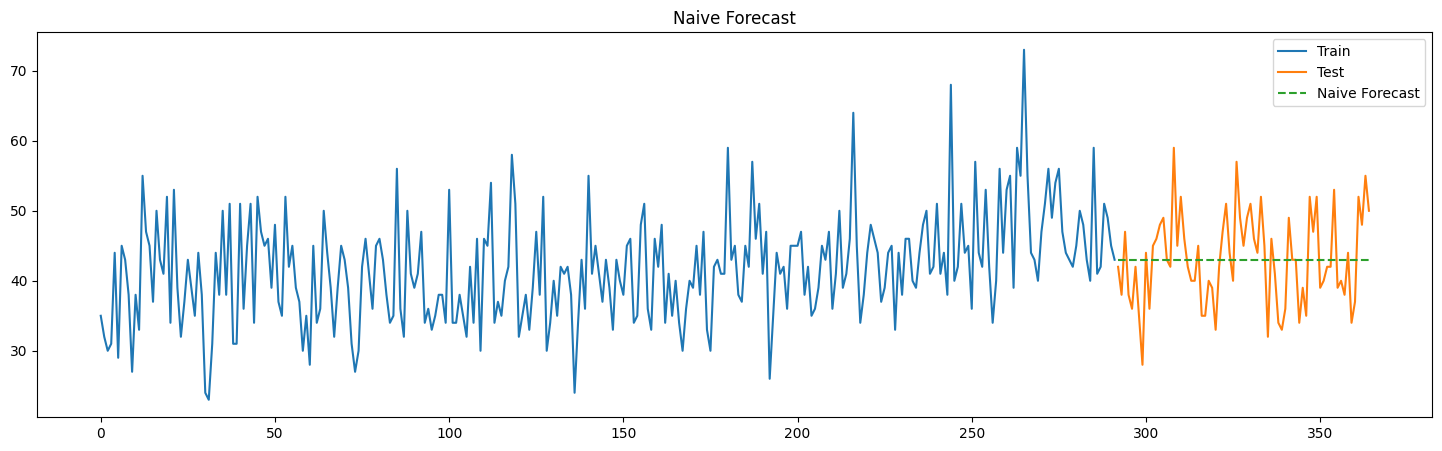

In [13]:
# Model 1 : Native forcast
naive_forecast = np.repeat(train['Births'].iloc[-1], len(test))

plt.figure(figsize=(18,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.plot(test.index, naive_forecast, label='Naive Forecast', linestyle='--')
plt.title('Naive Forecast')
plt.legend()
plt.show()

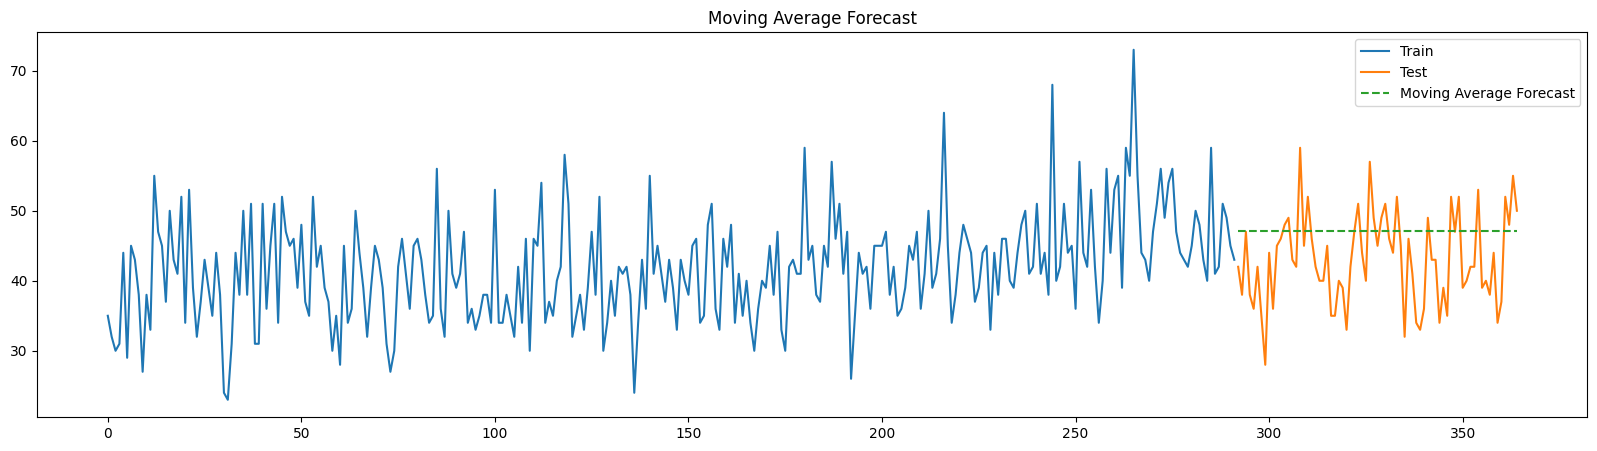

In [14]:
# Model 2 : Moving Average Forecast
window = 7 # consider 7 day avg calculation window 
ma_value = train['Births'].rolling(window).mean().iloc[-1]
ma_forecast = [ma_value] * len(test)

plt.figure(figsize=(20,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.plot(test.index, ma_forecast, label='Moving Average Forecast', linestyle='--')
plt.title('Moving Average Forecast')
plt.legend()
plt.show()


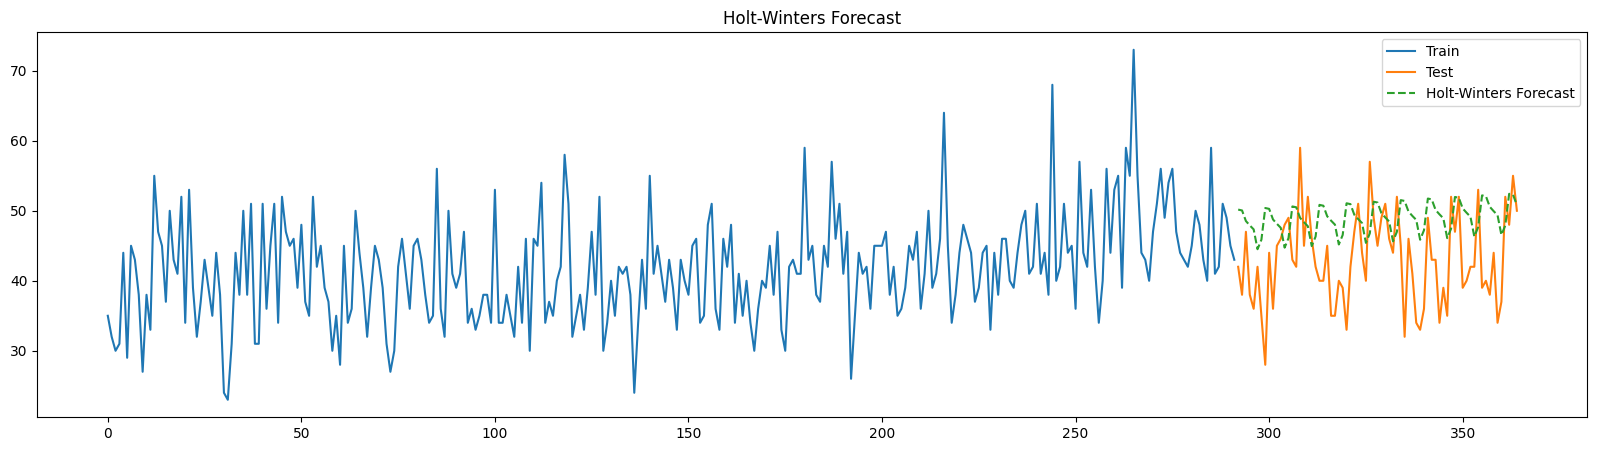

In [15]:
# Model 3 :Holt-Winters
hw_model = ExponentialSmoothing(
    train['Births'],
    trend='additive',
    seasonal='additive',
    seasonal_periods=7
).fit()
hw_forecast = hw_model.forecast(len(test))
plt.figure(figsize=(20,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', linestyle='--')
plt.title('Holt-Winters Forecast') # trained+weekly seasoned data
plt.legend()
plt.show()


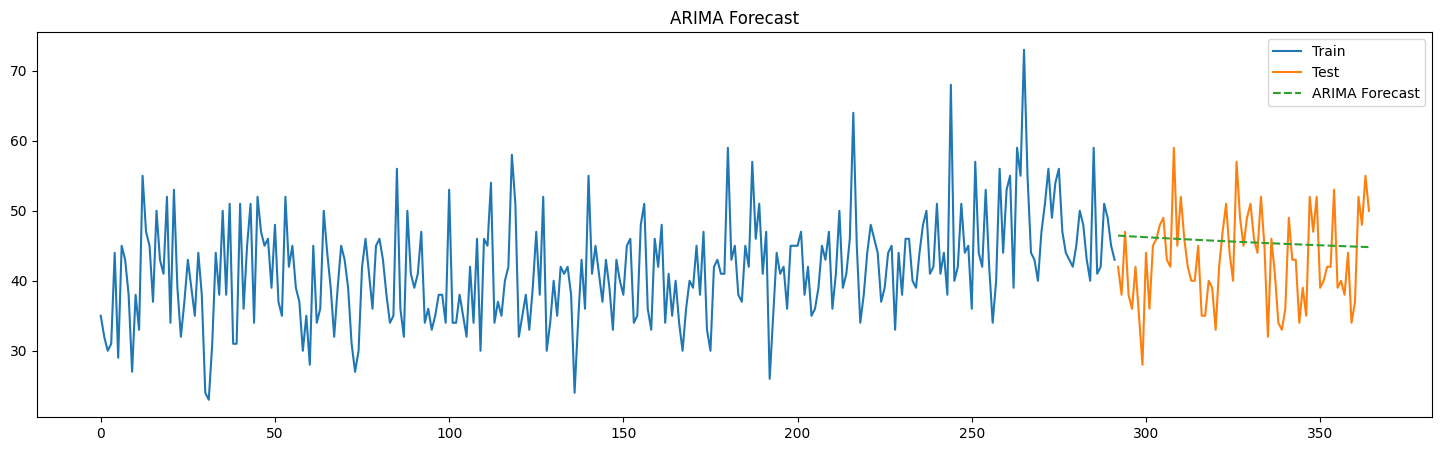

In [16]:
# Model 4 : ARIMA (prediction of avg value and underdrift  )
arima_model = ARIMA(train['Births'], order=(1,0,1))# d=0 flat capture
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(18,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Forecast') 
plt.legend()
plt.show()

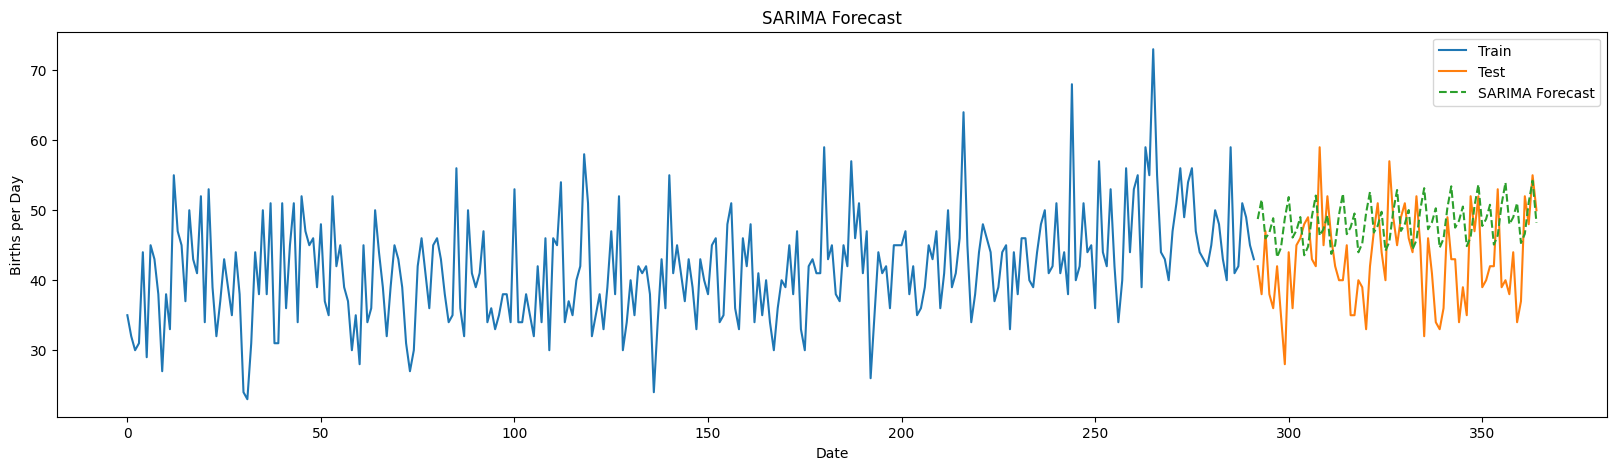

In [17]:
# Model 5 : 
# Fit SARIMA model
sarima_model = SARIMAX(
    train['Births'],
    order=(1, 0, 1),               # model order
    seasonal_order=(1, 0, 1, 7),   # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))
# Plot
plt.figure(figsize=(20,5))
plt.plot(train['Births'], label='Train')
plt.plot(test['Births'], label='Test')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', linestyle='--') #smoother and closer to original 
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Births per Day')
plt.legend()
plt.show() 

**Evaluation**

Chose one of the errors used for the evaluation explained in class and use it to compare the models.

In [18]:
# Manual Evaluation
y_true = test['Births']
results = {
    "Model": [
        "Naive",
        "Moving Average",
        "Holt-Winters",
        "ARIMA",
        "SARIMA"
    ],
    "MSE": [
        mean_squared_error(y_true, naive_forecast),
        mean_squared_error(y_true, ma_forecast),
        mean_squared_error(y_true, hw_forecast),
        mean_squared_error(y_true, arima_forecast),
        mean_squared_error(y_true, sarima_forecast)     # mean square error
    ],
    "MAE": [
        mean_absolute_error(y_true, naive_forecast),
        mean_absolute_error(y_true, ma_forecast),
        mean_absolute_error(y_true, hw_forecast),
        mean_absolute_error(y_true, arima_forecast),
        mean_absolute_error(y_true, sarima_forecast)    #Mean Absolute error
    ]
}
results_df = pd.DataFrame(results)
results_df

,Model,MSE,MAE
0,Naive,41.260274,5.232877
1,Moving Average,58.196533,6.291585
2,Holt-Winters,79.102432,7.461442
3,ARIMA,48.592797,5.712746
4,SARIMA,78.302416,7.286238


Which model is the best? For which forecasting horizon?

*#answer here*

To find the best forecasting model, the models were compared using Mean Squared Error (MSE) and Mean Absolute Error (MAE). These error measures show how different the predicted values are from the actual values, and smaller values indicate better forecasting performance.

Based on the results, the Naive model has the lowest MSE and MAE compared to the other models. This means that the Naive model produces predictions that are closest to the actual number of daily female births in the test dataset.

The reason why the Naive model performs best is that the time series does not show strong trends or very complex seasonal patterns. Although the values fluctuate from day to day, they remain around a similar level over time. Because of this, using the last observed value as the forecast works well for short periods.

Therefore, the Naive model is the best model for short-term forecasting horizons, such as the test period used in this assignment. More complex models like ARIMA, Holt-Winters, or SARIMA may be more suitable for longer forecasting horizons or datasets with stronger trends and seasonality, but for this dataset and forecasting horizon, the Naive model performs better.

**(Bonus): Cross-Validation**

In [19]:
# Cross-Validation
# Time series split
tscv = TimeSeriesSplit(n_splits=5)  # split data into 5 folds as earlier data training data

mse_naive = []
mse_ma = []
mse_hw = []
mse_arima = []
mse_sarima = [] # 5 models of data 
# Loop through each CV fold (5 folds total)
for train_idx, test_idx in tscv.split(data):    
    train_cv = data.iloc[train_idx]['Births']
    test_cv = data.iloc[test_idx]['Births']
    h = len(test_cv)

    # Naive- Predicts last training value for all future points
    naive_pred = np.repeat(train_cv.iloc[-1], h)
    mse_naive.append(mean_squared_error(test_cv, naive_pred))

    # Moving Average - Uses the mean of last 7 training values
    ma_value = train_cv.rolling(7).mean().iloc[-1]
    ma_pred = np.repeat(ma_value, h)
    mse_ma.append(mean_squared_error(test_cv, ma_pred))

    # Holt-Winters - Learns level + trend + seasonality (weekly period = 7)
    hw_model = ExponentialSmoothing(
        train_cv,
        trend='add',
        seasonal='add',
        seasonal_periods=7
    ).fit()
    hw_pred = hw_model.forecast(h)
    mse_hw.append(mean_squared_error(test_cv, hw_pred))
    # ARIMA - 
    arima_model = ARIMA(train_cv, order=(1,0,1)).fit()
    arima_pred = arima_model.forecast(h)
    mse_arima.append(mean_squared_error(test_cv, arima_pred))
    # SARIMA
    sarima_model = SARIMAX(
        train_cv,
        order=(1,0,1),
        seasonal_order=(1,0,1,7)
    ).fit(disp=False)
    sarima_pred = sarima_model.forecast(h)
    mse_sarima.append(mean_squared_error(test_cv, sarima_pred))
# Final table : average MSE all 5 folder 
cv_results = {
    "Model": ["Naive", "Moving Average", "Holt-Winters", "ARIMA", "SARIMA"],
    "Average MSE (CV)": [
        np.mean(mse_naive),
        np.mean(mse_ma),
        np.mean(mse_hw),
        np.mean(mse_arima),
        np.mean(mse_sarima)
    ]
}
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,Average MSE (CV)
0,Naive,177.380000
1,Moving Average,49.121769
2,Holt-Winters,50.871313
3,ARIMA,54.231124
4,SARIMA,49.043338


Is the best model the same as before? For which forecasting horizon?

*#answer here*

No, the best model is not the same as before. In the single train-test split evaluation, the Naive model performed best with the lowest MSE and MAE. However, in cross-validation, the Moving Average model has the lowest average MSE (48.94), making it the best overall across multiple forecasting horizons.

For which forecasting horizon?
The change in best model suggests that:
- Naive works best for very short-term forecasts (one-step ahead), where the last observed value is a good predictor.
- Moving Average performs better across varying and potentially longer horizons because it smooths out daily noise and captures the average level more consistently over different test periods.

Cross-validation tests models on multiple test segments, not just one, so it gives a more reliable measure of how each model generalizes across different time windows. Here, Moving Average shows stronger stability across splits, while Naive performs well only on certain short horizons but poorly on others (as seen by its high average MSE in CV). This indicates that Moving Average is more robust for general forecasting use, while Naive is only optimal for specific short-horizon scenarios.
